In [1]:
import argparse
import csv
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import random
import scanpy as sc
from torch.utils.data import DataLoader
from model.model import MIL

In [2]:
from torch.utils.data import Dataset
import pandas as pd
import scanpy as sc
import numpy as np
import torch
import scipy.sparse as sp
from scipy.spatial.distance import cdist
from tqdm import trange
from scipy.sparse import issparse


# ────────────────────────────────────────────────────────────────
#  bags_dataset.py
# ────────────────────────────────────────────────────────────────
import numpy as np
import torch
from torch.utils.data import Dataset
from tqdm import trange
from scipy.spatial.distance import cdist
import scipy.sparse as sp

# ----------------------------------------------------------------
# 1. Immune-cell shorthand → column name
# ----------------------------------------------------------------
def map_immune_cell(tag: str) -> str:
    mapping = {
        "tcell":       "T",
        "bcell":       "B",
        "macrophage":  "Macrophage",
        "neutrophil":  "Neutrophil",
        "fibroblast":  "Fibroblast",
        "endothelial": "Endothelial",
    }
    if tag in mapping:
        return mapping[tag]
    raise ValueError(f"Invalid immune cell type: {tag}")


# ----------------------------------------------------------------
# 2. Pre-processing (gene filtering, optional label handling)
# ----------------------------------------------------------------
def preprocess_data(adata, immune_cell, n_genes=500, resolution="low"):
    """
    • Select top-expressed genes + hand-curated tumour/ HLA genes
    • If immune_cell is None   → skip all label logic, create dummy column
    • If immune_cell provided → ensure binary label in adata.obs[immune_cell]
    """
    from scipy.sparse import issparse

    has_label = immune_cell is not None
    if has_label and immune_cell not in adata.obs.columns:
        immune_cell = map_immune_cell(immune_cell)

    adata = adata.copy()
    adata.var_names_make_unique()

    # -------- filter tumour cells (cell_type == 1) ----------------
    tumour = adata[adata.obs["cell_type"].astype(int) == 1].copy()

    # -------- pick genes -----------------------------------------
    if issparse(tumour.X):
        mean_expr = np.asarray(tumour.X.mean(axis=0)).ravel()
    else:
        mean_expr = tumour.X.mean(axis=0)

    gene_names = tumour.var_names
    n_genes = min(n_genes, int(0.2 * len(gene_names))) if n_genes > len(gene_names) else n_genes
    top_idx  = mean_expr.argsort()[-n_genes:][::-1]
    top_genes = gene_names[top_idx]

    tumour_gene_set = [
        # tumour antigens / oncogenes (short list shown here – extend as needed)
        "PRAME", "MUC1", "EPCAM", "PMEL", "MAGEA3", "WT1",
        "MYC", "CCND1", "CDK4", "CDK6", "BCL2", "BIRC5",
    ]
    hla_genes = [g for g in adata.var_names if g.startswith("HLA")]

    keep = list(dict.fromkeys(tumour_gene_set + hla_genes + list(top_genes)))
    drop = {"CD68", "STAT1", "MMP13"}  # example exclusion list
    keep = [g for g in keep if g in adata.var_names and g not in drop]

    adata = adata[:, keep].copy()

    # -------- label handling -------------------------------------
    if has_label:
        adata.obs[immune_cell] = adata.obs[immune_cell].astype(float)

        if resolution != "high":
            if not set(adata.obs[immune_cell].unique()).issubset({0, 1}):
                thresh = np.percentile(
                    adata[adata.obs["cell_type"] == 1].obs[immune_cell], 75
                )
                adata.obs[immune_cell] = (adata.obs[immune_cell] > thresh).astype(int)
    else:
        # create dummy label so downstream code always finds a column
        adata.obs["dummy_label"] = -1
        immune_cell = "dummy_label"

    return adata


# ----------------------------------------------------------------
# 3. BagsDataset
# ----------------------------------------------------------------
class BagsDataset(Dataset):
    """
    mode="train": each __getitem__ returns *one batch* = [pos + k-1 neg] bags
    mode="infer": each __getitem__ returns *one bag* (label = -1)
    """
    def __init__(
        self,
        input_data,                 # AnnData or CSV path
        immune_cell="tcell",
        max_instances=None,
        radius=200,
        resolution="low",
        n_genes=500,
        k=2,
        mode="train",
    ):
        import scanpy as sc, pandas as pd    # local import to avoid hard dep

        self.mode = mode.lower()             # "train" | "infer"
        self.k    = k                        # train: 1 pos + k-1 neg
        self.radius     = radius
        self.resolution = resolution
        self.max_instances = max_instances
        self.n_genes = n_genes

        # Only map immune_cell during training
        self.immune_cell = (
            map_immune_cell(immune_cell) if (immune_cell and self.mode == "train") else None
        )

        if isinstance(input_data, str):
            # CSV file with columns: adata, radius (opt), resolution (opt)
            df = pd.read_csv(input_data)
            adata_list = []
            for _, row in df.iterrows():
                ad = sc.read_h5ad(row["adata"])
                r  = row.get("radius",      self.radius)
                res = row.get("resolution", self.resolution)
                ad_prep = preprocess_data(ad, self.immune_cell, n_genes, res)
                adata_list.append((ad_prep, r, res))
            self.batches = self._build_bags(adata_list)

        elif hasattr(input_data, "X"):  # AnnData
            ad = preprocess_data(input_data, self.immune_cell, n_genes, resolution)
            self.batches = self._build_bags([(ad, radius, resolution)])
        else:
            raise ValueError("input_data must be an AnnData object or a CSV path")

    # ---------- torch Dataset API ----------
    def __len__(self):
        return len(self.batches)

    def __getitem__(self, idx):
        return self.batches[idx]

    # ---------- bag builder ----------
    def _build_bags(self, adata_radius_list):
        train_batches, infer_items = [], []

        for adata, radius, resolution in adata_radius_list:
            coords = adata.obs[["X", "Y"]].astype(float).to_numpy()
            expr   = adata.X
            barcodes   = adata.obs_names.to_numpy()
            gene_names = adata.var_names.tolist()

            # labels: real during training, dummy (-1) during inference
            if self.mode == "train":
                labels = adata.obs[self.immune_cell].astype(int).to_numpy()
            else:
                labels = np.full(adata.n_obs, -1, dtype=int)

            cell_types = adata.obs["cell_type"].astype(int).to_numpy()

            pos_bags, neg_bags = [], []

            for i in trange(adata.n_obs, desc=f"[{self.mode}] r={radius}", leave=False):
                # Only tumor cells are allowed to be bag centers
                if cell_types[i] == 0:
                    continue

                dist = cdist([coords[i]], coords)[0]
                neigh = np.where(dist <= radius)[0]
                neigh = neigh[cell_types[neigh] == 1]          # tumor neighbors only
                if resolution == "high":
                    neigh = neigh[neigh != i]                  # optionally drop self

                if len(neigh) == 0:
                    continue
                if self.max_instances and len(neigh) > self.max_instances:
                    continue

                bag = {
                    "distances":      dist[neigh, None].astype(np.float32),
                    "gene_expression": expr[neigh],
                    "label":          labels[i],
                    "core_idx":       i,
                    "gene_names":     gene_names,
                    "cell_id":        barcodes[i],
                }

                if self.mode == "train":
                    (pos_bags if labels[i] == 1 else neg_bags).append(bag)
                else:
                    infer_items.append(bag)

            # Assemble train batches: 1 pos + k-1 neg
            if self.mode == "train":
                k_neg = self.k - 1
                n_batch = min(len(pos_bags), len(neg_bags) // k_neg) if k_neg else len(pos_bags)
                if n_batch == 0:
                    continue
                np.random.shuffle(neg_bags)
                pos_bags = pos_bags[:n_batch]
                neg_bags = neg_bags[:n_batch * k_neg]
                for b in range(n_batch):
                    train_batches.append(
                        [pos_bags[b]] + neg_bags[b * k_neg : (b + 1) * k_neg]
                    )

        return train_batches if self.mode == "train" else infer_items


# ----------------------------------------------------------------
# 4. Collate function (train / infer unified)
# ----------------------------------------------------------------
def custom_collate_fn(batch):
    """
    • train  : batch[0] is a list of bags (pos + negs)
    • infer  : batch is a list of single-bag dicts
    Returns six parallel lists / tensors for flexibility downstream.
    """
    # Identify mode from structure
    bags = batch[0] if isinstance(batch[0], list) else batch

    dists, exprs, labels, cores, gnames, cids = [], [], [], [], [], []
    for bag in bags:
        dists.append(torch.tensor(bag["distances"], dtype=torch.float32))

        ge = bag["gene_expression"]
        if sp.issparse(ge):
            ge = ge.todense()
        exprs.append(torch.tensor(ge, dtype=torch.float32))

        labels.append(torch.tensor(bag["label"], dtype=torch.float32))
        cores.append(bag["core_idx"])
        gnames.append(bag["gene_names"])
        cids.append(bag["cell_id"])

    return dists, exprs, labels, cores, gnames, cids


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def load_all_genes(reference_gene_file):
    all_genes = []
    with open(reference_gene_file, 'r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            all_genes.append(row['Gene'])
    return all_genes

all_genes = load_all_genes('data/human_filtered.csv')

In [5]:
model_path = 'finalize_model/tcell/model_epoch_9.pth'
all_genes_df = pd.read_csv('data/human_filtered.csv')  # Replace with your reference gene file path
all_genes = all_genes_df['Gene'].tolist()

# Initialize the model
model = MIL(all_genes).to(device)

In [6]:
len(all_genes)

23182

In [7]:
model.load_state_dict(torch.load(model_path, map_location=device))


<All keys matched successfully>

In [8]:
model.state_dict()

OrderedDict([('alpha', tensor(4.0484, device='cuda:0')),
             ('beta', tensor(-4.3619, device='cuda:0')),
             ('distance.a', tensor(-0.6811, device='cuda:0')),
             ('gene_expression.b', tensor(-0.9713, device='cuda:0')),
             ('immunogenicity.ig',
              tensor([-1.3999e-42, -3.5400e+00, -1.3999e-42,  ..., -1.2754e+01,
                      -1.2791e+01, -1.3999e-42], device='cuda:0'))])

## SPACER Gene Score Visualization

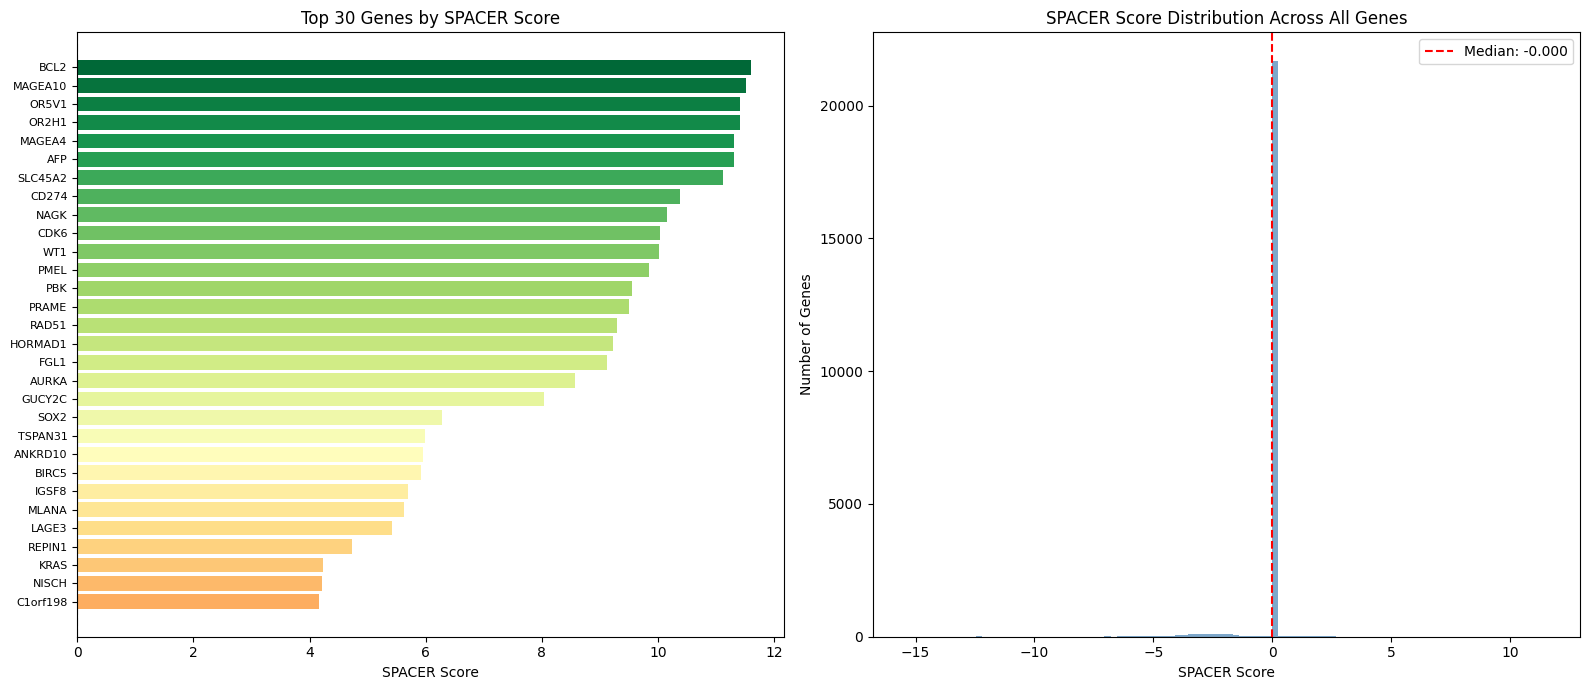

In [9]:
import matplotlib.pyplot as plt
import numpy as np

ig_scores = model.immunogenicity.ig.clone().detach().cpu().numpy()
gene_arr = np.array(all_genes)

top_idx = np.argsort(ig_scores)[-30:][::-1]
top_genes_spacer = gene_arr[top_idx]
top_scores_spacer = ig_scores[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = plt.cm.RdYlGn(np.linspace(0.3, 1.0, 30))
axes[0].barh(range(30), top_scores_spacer[::-1], color=colors)
axes[0].set_yticks(range(30))
axes[0].set_yticklabels(top_genes_spacer[::-1], fontsize=8)
axes[0].set_xlabel('SPACER Score')
axes[0].set_title('Top 30 Genes by SPACER Score')
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5)

axes[1].hist(ig_scores, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
axes[1].set_xlabel('SPACER Score')
axes[1].set_ylabel('Number of Genes')
axes[1].set_title('SPACER Score Distribution Across All Genes')
axes[1].axvline(x=np.median(ig_scores), color='red', linestyle='--',
                label=f'Median: {np.median(ig_scores):.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:

# Load the prediction dataset
adata = sc.read('/work/DPDS/s439765/data4spacer/spatial_transcriptomics/linghua_cosmx/GAME3D6/d6_sample1_Tcell.h5ad')
prediction_dataset = BagsDataset(adata, immune_cell='tcell', radius=60, n_genes=5000, resolution='high',mode='infer')
prediction_dataloader = torch.utils.data.DataLoader(prediction_dataset, batch_size=1, collate_fn=custom_collate_fn)
adata.obs['T_pred'] = np.nan



In [ ]:
def print_avg_instances(dataset):
    # dataset.batches: list of train batches (each batch = list of bags)
    # flatten to get all bags
    if dataset.mode == "train":
        all_bags = [bag for batch in dataset.batches for bag in batch]
    else:
        all_bags = dataset.batches

    sizes = [bag["gene_expression"].shape[0] for bag in all_bags]
    print("Number of bags:", len(sizes))
    print("Average instances per bag:", np.mean(sizes))
    print("Std:", np.std(sizes))
    print("Min:", np.min(sizes))
    print("Max:", np.max(sizes))
ds = BagsDataset(adata, immune_cell="tcell", mode="val", radius=60)
print_avg_instances(ds)

Number of bags: 33545
Average instances per bag: 51.36130570874944
Std: 16.9602878244647
Min: 1
Max: 126


In [ ]:
adata.X.shape

(56900, 20385)

In [ ]:
adata.obs

,fov,Area,AspectRatio,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68,Max.CD68,Mean.Membrane,...,sample,anno,anno_sub,cell_type,T,B,Endothelial,Macrophage,Fibroblast,T_pred
cell_id,,,,,,,,,,,,,,,,,,,,,
c_319_1623,319,12265,0.89,140,157,10270,51696,662,2688,2326,...,cosmx,Epi,Parietal,1,0,0,0,0,0,NaN
c_324_1617,324,7738,0.86,141,121,3486,5960,468,1096,2835,...,cosmx,Epi,Parietal,1,0,0,0,0,0,NaN
c_329_1090,329,8842,0.89,117,131,2700,8060,400,896,2707,...,cosmx,Epi,chief,1,0,0,0,0,0,NaN
c_306_257,306,12183,0.96,136,130,3149,25608,366,2140,2168,...,cosmx,Epi,chief,1,0,0,0,0,0,NaN
c_313_1252,313,7048,0.81,108,88,3980,9060,437,1272,2492,...,cosmx,Epi,chief,1,0,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_331_1372,331,3431,0.92,73,67,5716,15972,421,784,3035,...,cosmx,Epi,Parietal,1,0,0,0,0,0,NaN
c_333_461,333,3840,0.85,64,75,3342,8628,579,960,3278,...,cosmx,Epi,Parietal,1,0,0,0,0,0,NaN
c_316_169,316,6299,0.67,90,135,1043,2256,262,404,280,...,cosmx,CAFs,SMCs,0,0,0,0,0,0,NaN


In [ ]:
import torch

def predict(model, prediction_dataloader, adata, device='cuda'):
    """
    Perform prediction/inference using the given model and dataloader, and store
    the predictions in `adata.obs`.

    Args:
        model (nn.Module): The trained model to use for inference.
        prediction_dataloader (DataLoader): Dataloader that yields batches of
            (distances_list, gene_expressions_list, labels_list, core_idxs_list,
             gene_names_list, cell_ids_list).
        adata (AnnData): The annotated data object where predictions will be stored.
        device (str, optional): The device to run predictions on. Default is 'cuda'.

    Returns:
        None. The predictions are stored in `adata.obs` under the column 'T_pred'.
    """

    model.eval()
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    print(f"Using device for prediction: {device}")

    with torch.no_grad():
        for batch_data in prediction_dataloader:
            # Unpack the batch. Each batch contains lists of tensors/objects:
            # distances_list, gene_expressions_list, labels_list, core_idxs_list,
            # gene_names_list, cell_ids_list.
            (
                distances_list, 
                gene_expressions_list, 
                labels_list,        # Might not be needed for inference, but still returned.
                core_idxs_list, 
                gene_names_list, 
                cell_ids_list
            ) = batch_data

            # Move data to the appropriate device (GPU or CPU).
            distances_list = [distances.to(device) for distances in distances_list]
            gene_expressions_list = [gene_exp.to(device) for gene_exp in gene_expressions_list]

            # Forward pass through the model.
            outputs = model(distances_list, gene_expressions_list, gene_names_list)

            # If the model returns None (e.g., due to skipping certain batches), skip them.
            if outputs is None:
                continue

           
            for output, cell_id in zip(outputs, cell_ids_list):
                # Detach from GPU and convert to Python float.
                prediction = output.cpu().item()
                # Store the prediction in adata.obs using the matching cell_id.
                adata.obs.loc[cell_id, 'T_pred'] = prediction
                print(f"cell_id={cell_id}, prediction={prediction}")


In [ ]:
predict(model, prediction_dataloader, adata)

Using device for prediction: cpu
cell_id=c_319_1623, prediction=0.9999994039535522
cell_id=c_324_1617, prediction=1.0
cell_id=c_329_1090, prediction=1.0
cell_id=c_306_257, prediction=1.0
cell_id=c_313_1252, prediction=1.0
cell_id=c_292_1220, prediction=0.9999967813491821
cell_id=c_289_657, prediction=0.9999998807907104
cell_id=c_292_1089, prediction=1.0
cell_id=c_288_130, prediction=0.999988317489624
cell_id=c_329_1590, prediction=1.0
cell_id=c_281_1702, prediction=1.0
cell_id=c_329_1750, prediction=1.0
cell_id=c_333_333, prediction=1.0
cell_id=c_268_1396, prediction=0.999988317489624
cell_id=c_293_785, prediction=1.0
cell_id=c_329_781, prediction=1.0
cell_id=c_305_1932, prediction=1.0
cell_id=c_296_29, prediction=0.9999942779541016
cell_id=c_305_1265, prediction=1.0
cell_id=c_298_241, prediction=1.0
cell_id=c_325_610, prediction=1.0
cell_id=c_333_843, prediction=1.0
cell_id=c_317_966, prediction=0.9999891519546509
cell_id=c_318_2489, prediction=1.0
cell_id=c_318_2438, prediction=1.0
c

cell_id=c_332_639, prediction=1.0
cell_id=c_292_1882, prediction=0.999984622001648
cell_id=c_303_1629, prediction=0.9999879598617554
cell_id=c_304_1981, prediction=0.03579791635274887
cell_id=c_305_997, prediction=1.0
cell_id=c_331_635, prediction=1.0
cell_id=c_327_206, prediction=0.999946117401123
cell_id=c_282_542, prediction=1.0
cell_id=c_294_1502, prediction=1.0
cell_id=c_312_1004, prediction=1.0
cell_id=c_288_1341, prediction=0.9999805688858032
cell_id=c_323_1036, prediction=0.9999878406524658
cell_id=c_330_668, prediction=0.999987006187439
cell_id=c_333_578, prediction=1.0
cell_id=c_328_1532, prediction=0.9999988079071045
cell_id=c_327_1318, prediction=1.0
cell_id=c_305_1107, prediction=1.0
cell_id=c_296_653, prediction=0.9999865293502808
cell_id=c_288_67, prediction=0.999988317489624
cell_id=c_328_1215, prediction=1.0
cell_id=c_304_1853, prediction=0.9999798536300659
cell_id=c_323_786, prediction=0.9999698400497437
cell_id=c_328_1878, prediction=1.0
cell_id=c_320_779, prediction

In [26]:
adata.obs

,fov,Area,AspectRatio,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68,Max.CD68,Mean.Membrane,...,sample,anno,anno_sub,cell_type,T,B,Endothelial,Macrophage,Fibroblast,T_pred
cell_id,,,,,,,,,,,,,,,,,,,,,
c_319_1623,319,12265,0.89,140,157,10270,51696,662,2688,2326,...,cosmx,Epi,Parietal,1,0,0,0,0,0,0.999528
c_324_1617,324,7738,0.86,141,121,3486,5960,468,1096,2835,...,cosmx,Epi,Parietal,1,0,0,0,0,0,1.000000
c_329_1090,329,8842,0.89,117,131,2700,8060,400,896,2707,...,cosmx,Epi,chief,1,0,0,0,0,0,1.000000
c_306_257,306,12183,0.96,136,130,3149,25608,366,2140,2168,...,cosmx,Epi,chief,1,0,0,0,0,0,1.000000
c_313_1252,313,7048,0.81,108,88,3980,9060,437,1272,2492,...,cosmx,Epi,chief,1,0,0,0,0,0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_331_1372,331,3431,0.92,73,67,5716,15972,421,784,3035,...,cosmx,Epi,Parietal,1,0,0,0,0,0,0.999238
c_333_461,333,3840,0.85,64,75,3342,8628,579,960,3278,...,cosmx,Epi,Parietal,1,0,0,0,0,0,1.000000
c_316_169,316,6299,0.67,90,135,1043,2256,262,404,280,...,cosmx,CAFs,SMCs,0,0,0,0,0,0,NaN


In [27]:
mask = ~adata.obs['T_pred'].isna()
adata = adata[mask].copy()

In [28]:
adata.obs['T'].value_counts()   

T
0    30878
1     2642
Name: count, dtype: int64

In [29]:
adata.obs['T_pred'].fillna(value=0, inplace=True) 

/tmp/ipykernel_2931199/2272360687.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs['T_pred'].fillna(value=0, inplace=True)


In [30]:
#auroc 
from sklearn.metrics import roc_auc_score
roc_auc_score(adata.obs['T'], adata.obs['T_pred'])


0.2114637229007872

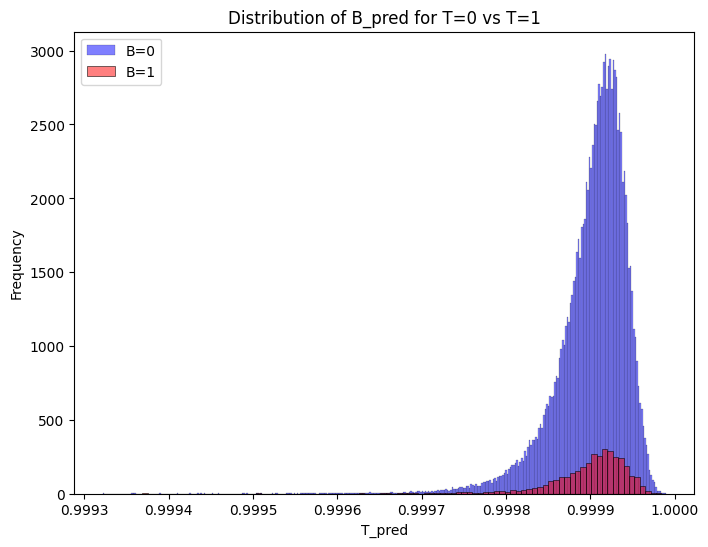

In [25]:
df = adata.obs.dropna(subset=['T_pred', 'T']).copy()
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.histplot(df.loc[df['T'] == 0, 'T_pred'], 
             color='blue', alpha=0.5, label='B=0')
sns.histplot(df.loc[df['T'] == 1, 'T_pred'], 
             color='red', alpha=0.5, label='B=1')
plt.legend()
plt.xlabel('T_pred')
plt.ylabel('Frequency')
plt.title('Distribution of B_pred for T=0 vs T=1')
plt.show()


best: 0.282
Youden's J statistic: 0.215


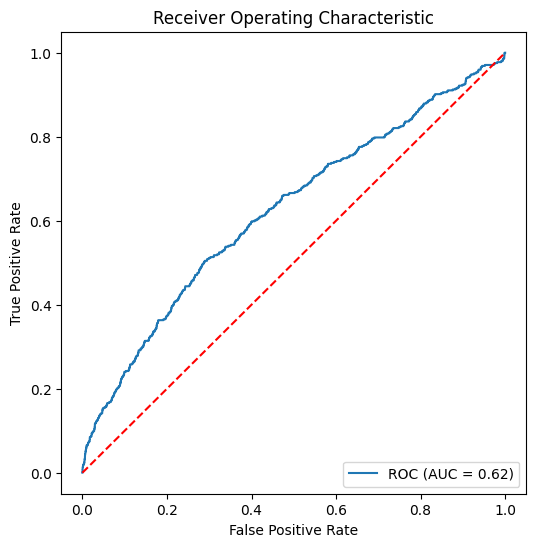

0.2824002206325531

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

df = adata.obs.dropna(subset=['T_pred', 'T']).copy()
df['T'] = df['T'].astype(int)

y_true = df['T']
y_score = df['T_pred']

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

youdenJ = tpr - fpr
ix = np.argmax(youdenJ)
best_thresh = thresholds[ix]

print(f'best: {best_thresh:.3f}')
print(f'Youden\'s J statistic: {youdenJ[ix]:.3f}')

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label='ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

best_thresh

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

df_pr = adata.obs.dropna(subset=['T_pred', 'T']).copy()
df_pr['T'] = df_pr['T'].astype(int)

precision_vals, recall_vals, _ = precision_recall_curve(df_pr['T'], df_pr['T_pred'])
ap = average_precision_score(df_pr['T'], df_pr['T_pred'])

baseline = df_pr['T'].mean()

plt.figure(figsize=(6, 6))
plt.plot(recall_vals, precision_vals, color='darkorange', lw=2,
         label=f'AP = {ap:.3f}')
plt.axhline(y=baseline, color='navy', linestyle='--',
            label=f'Baseline (prevalence = {baseline:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
#binarize the prediction,percentile is 0.5 as threshold, <0.5 as 0,>0.5 as 1
threshold_val = np.percentile(adata.obs['T_pred'], 50)
print(f"Threshold value: {threshold_val}")
adata.obs['T_pred_binary'] = (adata.obs['T_pred'] >= 0.4).astype(int)


Threshold value: 0.38019856810569763


## Spatial Map & Evaluation Metrics

In [ ]:
if 'X' in adata.obs.columns and 'Y' in adata.obs.columns:
    tumor_mask = adata.obs['cell_type'] == 1
    df_sp = adata.obs[tumor_mask].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sc_plot = axes[0].scatter(
        df_sp['X'], df_sp['Y'],
        c=df_sp['T_pred'], cmap='RdYlGn', s=3, alpha=0.5, vmin=0, vmax=1
    )
    plt.colorbar(sc_plot, ax=axes[0], label='T_pred Score')
    axes[0].set_title('Spatial Map of Prediction Scores')
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
    axes[0].invert_yaxis()

    color_map = {(0, 0): 'lightgray', (1, 0): 'royalblue',
                 (0, 1): 'orange',     (1, 1): 'crimson'}
    label_map = {(0, 0): 'TN', (1, 0): 'FP', (0, 1): 'FN', (1, 1): 'TP'}
    for (pred, truth), color in color_map.items():
        mask = (df_sp['T_pred_binary'] == pred) & (df_sp['T'] == truth)
        axes[1].scatter(
            df_sp.loc[mask, 'X'], df_sp.loc[mask, 'Y'],
            c=color, s=3, alpha=0.5, label=label_map[(pred, truth)]
        )
    axes[1].set_title('Spatial Map: TP / TN / FP / FN')
    axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
    axes[1].invert_yaxis()
    axes[1].legend(markerscale=4, loc='upper right')

    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

df_cm = adata.obs.dropna(subset=['T_pred_binary', 'T']).copy()
cm = confusion_matrix(df_cm['T'].astype(int), df_cm['T_pred_binary'].astype(int))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-T', 'T Cell'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (T Cell Prediction)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
prec = tp / (tp + fp) if (tp + fp) > 0 else 0
rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
print(f'Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}')
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')


In [ ]:
import seaborn as sns

if 'anno' in adata.obs.columns:
    df_anno = adata.obs.dropna(subset=['T_pred']).copy()
    order = df_anno.groupby('anno')['T_pred'].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.violinplot(data=df_anno, x='anno', y='T_pred', order=order, ax=ax, cut=0)
    ax.set_xlabel('Cell Annotation')
    ax.set_ylabel('Prediction Score')
    ax.set_title('T Cell Prediction Score by Cell Annotation')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
adata.obs['T_pred_binary'].value_counts()

Macrophage_pred_binary
0    121826
1     20818
Name: count, dtype: int64

In [ ]:
adata.obs['T'].value_counts()

Macrophage
0    137560
1      5084
Name: count, dtype: int64

In [ ]:
adata.obs[(adata.obs['T'] == 1) & (adata.obs['T_pred_binary'] == 1)]


,in_tissue,array_row,array_col,X,Y,n_genes,tumor_gene_signature,stromal_immune_gene_signature,t_gene_signature,b_gene_signature,...,fibroblast_gene_signature,leiden,T,B,Macrophage,Endothelial,Fibroblast,cell_type,Macrophage_pred,Macrophage_pred_binary
s_008um_00301_00218-1,1,301,218,1744,2408,273,3.526458,109.308022,3.526458,3.526458,...,11.936040,15,0,0,1,0,0,2,0.424755,1
s_008um_00552_00398-1,1,552,398,3184,4416,248,0.000000,92.369225,0.000000,3.638560,...,7.957036,15,0,0,1,0,0,2,0.426272,1
s_008um_00539_00331-1,1,539,331,2648,4312,243,0.000000,117.679749,0.000000,12.936357,...,7.705604,15,0,0,1,0,0,2,0.413867,1
s_008um_00577_00197-1,1,577,197,1576,4616,533,0.000000,154.682617,0.000000,2.834721,...,10.647765,15,0,0,1,0,0,2,0.404539,1
s_008um_00290_00489-1,1,290,489,3912,2320,284,3.446653,112.226013,0.000000,0.000000,...,7.970455,15,0,0,1,0,0,2,0.428030,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00250_00170-1,1,250,170,1360,2000,473,0.000000,149.151154,0.000000,5.759152,...,3.940030,15,0,0,1,0,0,2,0.405618,1
s_008um_00404_00038-1,1,404,38,304,3232,452,0.000000,106.860138,0.000000,5.978213,...,14.085390,15,0,0,1,0,0,2,0.419617,1
s_008um_00339_00089-1,1,339,89,712,2712,470,0.000000,137.420319,0.000000,5.895281,...,8.027275,15,0,0,1,0,0,2,0.401127,1
s_008um_00387_00091-1,1,387,91,728,3096,362,0.000000,127.474144,3.184208,3.184208,...,14.779366,15,0,0,1,0,0,2,0.408681,1


In [281]:
adata.write_h5ad('validation_tumor/pred_location/Colon_Cancer_P5Macrophage.h5ad')